In [1]:
import pandas as pd
import datetime as datetime
import matplotlib.pyplot as plt

df = pd.read_csv('hourly_pm2.5_data.csv')

In [ ]:
#need to make a fix for missing values! how to do this? Rei said 1/2 DL if missing, hmmmm


In [2]:
df

,Unnamed: 0,state_code,county_code,site_number,parameter_code,poc,latitude,longitude,datum,parameter,...,detection_limit,uncertainty,qualifier,method_type,method,method_code,state,county,date_of_last_change,cbsa_code
0,0,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FRM,R & P Model 2025 PM2.5 Sequential w/WINS - GRA...,118,Utah,Salt Lake,NaN,41620
1,1,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FRM,R & P Model 2025 PM2.5 Sequential w/WINS - GRA...,118,Utah,Salt Lake,NaN,41620
2,2,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FRM,R & P Model 2025 PM2.5 Sequential w/WINS - GRA...,118,Utah,Salt Lake,NaN,41620
3,3,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FRM,R & P Model 2025 PM2.5 Sequential w/WINS - GRA...,118,Utah,Salt Lake,NaN,41620
4,4,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FRM,R & P Model 2025 PM2.5 Sequential w/WINS - GRA...,118,Utah,Salt Lake,NaN,41620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220442,220442,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FEM,Thermo Scientific Model 5030 SHARP w/VSCC - Be...,184,Utah,Salt Lake,2026-08-11,41620
220443,220443,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FEM,Thermo Scientific Model 5030 SHARP w/VSCC - Be...,184,Utah,Salt Lake,2026-08-11,41620
220444,220444,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FEM,Thermo Scientific Model 5030 SHARP w/VSCC - Be...,184,Utah,Salt Lake,2026-08-11,41620
220445,220445,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FEM,Thermo Scientific Model 5030 SHARP w/VSCC - Be...,184,Utah,Salt Lake,2026-08-11,41620


In [3]:
#merge the data and the time columns
df["date_time_merged"] = df["date_local"] + ' ' + df["time_local"]
#create a proper datetime column
df["date_time"] = pd.to_datetime(df["date_time_merged"])

In [12]:
df["years"] = df["date_time"].dt.year
df["days"] = df["date_time"].dt.day
df["hours"] = df['date_time'].dt.hour
df["months"] = df['date_time'].dt.month
df["day of week"] = df['date_time'].dt.day_of_week
df["day of year"] = df['date_time'].dt.day_of_year


#set a start date so we can track days elapsed
start_date = df["date_time"].iloc[0]

df["date_time_elapsed"] = (df['date_time'] - start_date)

df["days_elapsed"] = df['date_time_elapsed'].dt.days

In [13]:
df["days_elapsed"]

0             0
1             1
2             2
3             3
4             4
          ...  
220442    10073
220443    10073
220444    10073
220445    10073
220446    10073
Name: days_elapsed, Length: 220447, dtype: int64

In [5]:
df["day of week"]

0         4
1         5
2         6
3         0
4         1
         ..
220442    4
220443    4
220444    4
220445    4
220446    4
Name: day of week, Length: 220447, dtype: int32

In [19]:
#df_24houravg = df[df["sample_duration"] == "24 HOUR"]

df_by_day = df.groupby(pd.Grouper(key="date_time", freq= "D")) #measurements grouped by day
df_by_day.head()
#this sorts by samples measured as 24 hours averages

,Unnamed: 0,state_code,county_code,site_number,parameter_code,poc,latitude,longitude,datum,parameter,...,date_time_merged,date_time,years,days,hours,months,day of week,day of year,days_elapsed,date_time_elapsed
0,0,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,1999-01-01 00:00,1999-01-01 00:00:00,1999,1,0,1,4,1,0,0 days 00:00:00
1,1,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,1999-01-02 00:00,1999-01-02 00:00:00,1999,2,0,1,5,2,1,1 days 00:00:00
2,2,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,1999-01-03 00:00,1999-01-03 00:00:00,1999,3,0,1,6,3,2,2 days 00:00:00
3,3,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,1999-01-04 00:00,1999-01-04 00:00:00,1999,4,0,1,0,4,3,3 days 00:00:00
4,4,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,1999-01-05 00:00,1999-01-05 00:00:00,1999,5,0,1,1,5,4,4 days 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210270,210270,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2026-07-31 00:00,2026-07-31 00:00:00,2026,31,0,7,4,212,10073,10073 days 00:00:00
215335,215335,49,35,3006,88101,4,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2026-07-31 00:00,2026-07-31 00:00:00,2026,31,0,7,4,212,10073,10073 days 00:00:00
220423,220423,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2026-07-31 00:00,2026-07-31 00:00:00,2026,31,0,7,4,212,10073,10073 days 00:00:00
215336,215336,49,35,3006,88101,4,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2026-07-31 01:00,2026-07-31 01:00:00,2026,31,1,7,4,212,10073,10073 days 01:00:00


In [23]:
df_by_day["days_elapsed"].head()

0             0
1             1
2             2
3             3
4             4
          ...  
210270    10073
215335    10073
220423    10073
215336    10073
220424    10073
Name: days_elapsed, Length: 29776, dtype: int64

In [24]:
df_by_day["sample_measurement"].head()

0         21.6
1         11.1
2         15.0
3          9.5
4         14.7
          ... 
210270     7.5
215335     9.7
220423    12.2
215336     9.8
220424    12.0
Name: sample_measurement, Length: 29776, dtype: float64

ConversionError: Failed to convert value(s) to axis units: <pandas.api.typing.SeriesGroupBy object at 0x000002B73437E8B0>

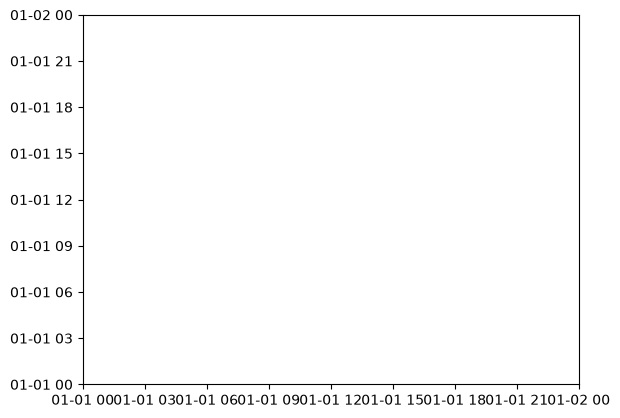

In [25]:
plt.scatter(df_by_day["days_elapsed"], df_by_day["sample_measurement"])
plt.show()